# Lab 2: Assestment of aircraft engine vanes quality using textural features

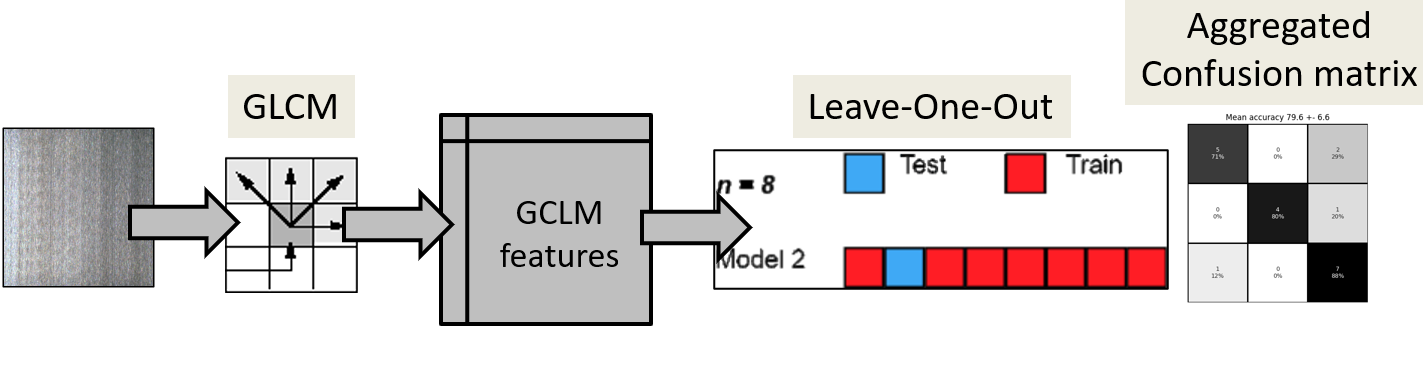

## Import and settings

In [396]:
import os
import glob
import skimage
import numpy as np
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import RandomizedSearchCV

In [397]:
!git clone https://github.com/frpnz/teaching-Roughness.git
ROOTDIR_DATASET = "/content/teaching-Roughness/data"

fatal: destination path 'teaching-Roughness' already exists and is not an empty directory.


## Functions

In [398]:
def seaborn_cm(cm, ax, tick_labels, fontsize=14, title=None, sum_actual="over_columns",
               xrotation=0, yrotation=0):
    """
    Function to plot a confusion matrix
    """
    from matplotlib import cm as plt_cmap
    group_counts = ["{:0.0f}".format(value) for value in cm.flatten()]
    if sum_actual == "over_columns":
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    elif sum_actual == "over_rows":
        cm = cm.astype('float') / cm.sum(axis=0)[:, np.newaxis]
    else:
        print("sum_actual must be over_columns or over_rows")
        exit()
    cm = np.nan_to_num(cm)
    mean_acc = np.mean(np.diag(cm)[cm.sum(axis=1) != 0])
    std_acc = np.std(np.diag(cm))
    group_percentages = ["{:0.0f}".format(value*100) for value in cm.flatten()]
    cm_labels = [f"{c}\n{p}%" for c, p in zip(group_counts, group_percentages)]
    cm_labels = np.asarray(cm_labels).reshape(len(tick_labels), len(tick_labels))
    sns.heatmap(cm,
                ax=ax,
                annot=cm_labels,
                fmt='',
                cbar=False,
                cmap=plt_cmap.Greys,
                linewidths=1, linecolor='black',
                annot_kws={"fontsize": fontsize},
                xticklabels=tick_labels,
                yticklabels=tick_labels)
    ax.set_yticklabels(ax.get_yticklabels(), size=fontsize, rotation=yrotation)
    ax.set_xticklabels(ax.get_xticklabels(), size=fontsize, rotation=xrotation)
    if title:
        title = f"{title}\nMean accuracy {mean_acc * 100:.1f} +- {std_acc * 100:.1f}"
    else:
        title = f"Mean accuracy {mean_acc * 100:.1f} +- {std_acc * 100:.1f}"
    ax.set_title(title)
    if sum_actual == "over_columns":
        ax.set_ylabel("Actual")
        ax.set_xlabel("Predicted")
    else:
        ax.set_ylabel("Predicted")
        ax.set_xlabel("Actual")

def my_imshow(image, title=None):
    fig, ax = plt.subplots(1, 1)
    if len(image.shape) > 2:
        ax.imshow(image)
    else:
        ax.imshow(image, cmap=plt.cm.gray)
    ax.axis("off")
    if title:
        ax.set_title(title)

#Assignment #1: Get all filepaths ending with `".bmp"`

In [399]:
import glob
import os
# با استفاده از glob تمام فایل‌هایی که پسوند .bmp دارند را در تمام زیرپوشه‌ها پیدا می‌کنیم
filepaths = glob.glob(os.path.join(ROOTDIR_DATASET, "**/*.bmp"), recursive=True)

# برای اطمینان از درست خواندن، تعداد را چاپ می‌کنیم
print(f"Total images found: {len(filepaths)}")

Total images found: 20


#Assignment #2: Plot some images from training set.

Create a single figure object with several subplots and remove axis where not needed.
Set the filename as title for the single subplot.

There exixt several packages to manipulate images in Python. Consider the following three, that are very popular:


*   [skimage](https://scikit-image.org/)
*   [Image module](https://pillow.readthedocs.io/en/stable/reference/Image.html) of Pillow
*   [OpenCV](https://pypi.org/project/opencv-python/)


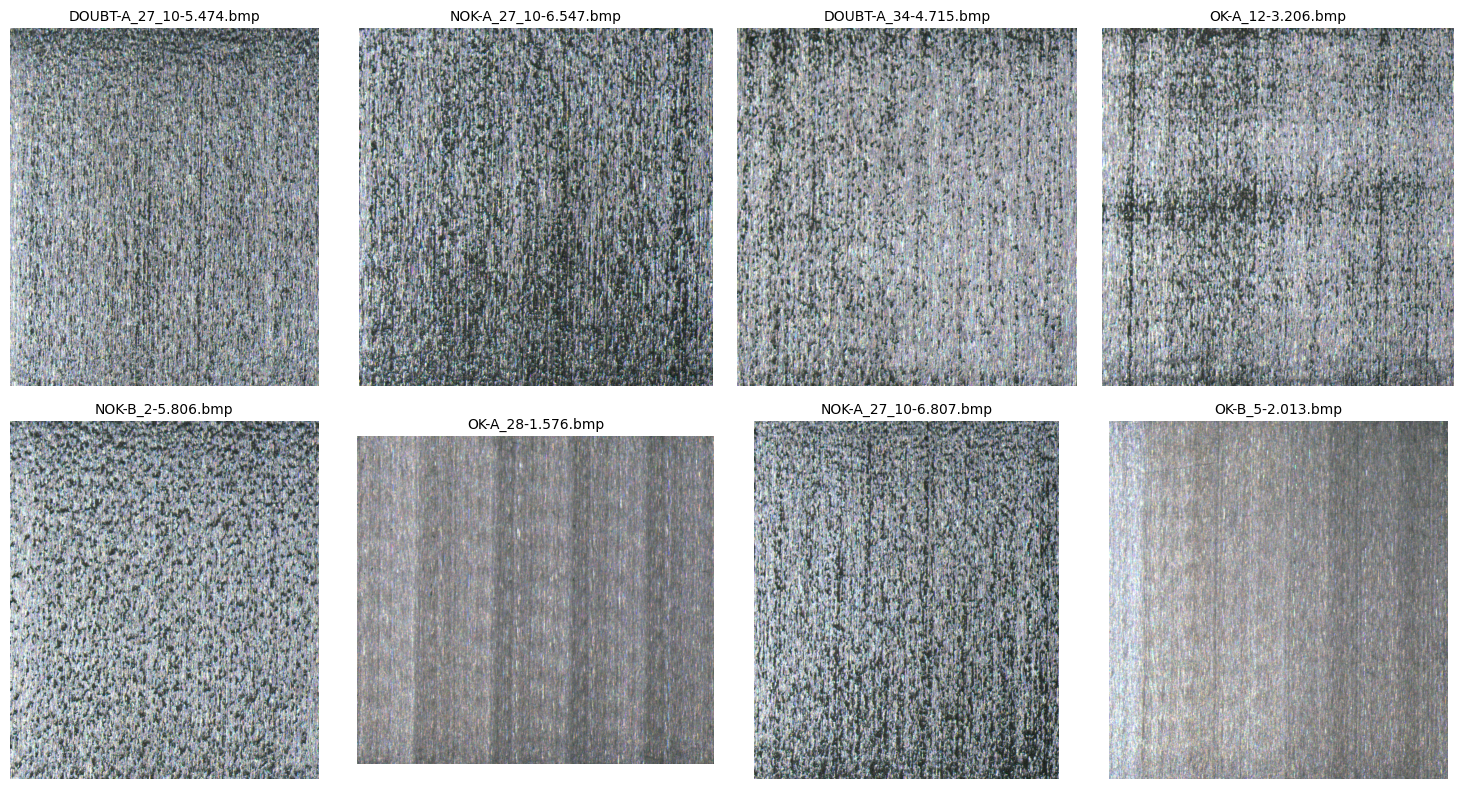

In [400]:
import cv2
import matplotlib.pyplot as plt

n_images = 8
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

for i in range(n_images):
    img = cv2.imread(filepaths[i])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img_rgb)

    filename = os.path.basename(filepaths[i])
    axes[i].set_title(filename, fontsize=10)

    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Assignment #3: extract the so-called Gray-Level Co-Occurrence matrix (GLCM)

The GLCM is computed by calculating how often a pixel with the intensity (gray-level) value i occurs in a specific spatial relationship to a pixel with the value j.

To illustrate, the following figure shows how graycomatrix calculates the first three values in a GLCM. In the output GLCM, element (1, 1) contains the value 1 because there is only one instance in the input image where two horizontally adjacent pixels have the values 1 and 1, respectively. Element (1, 2) contains the value 2 because there are two instances where two horizontally adjacent pixels have the values 1 and 2. Element (1, 3) has the value 0 because there are no instances of two horizontally adjacent pixels with the values 1 and 3. graycomatrix continues processing the input image, scanning the image for other pixel pairs (i, j) and recording the sums in the corresponding elements of the GLCM.

source: https://it.mathworks.com/help/images/create-a-gray-level-co-occurrence-matrix.html

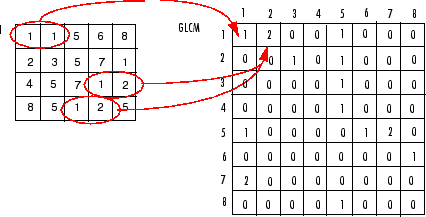

# Code the pipeline to extract the GLC from a single image.


Steps:

1. Some preprocssing operations are required. See the documentation of [skimage.feature.graycomatrix](https://scikit-image.org/docs/stable/api/skimage.feature.html#graycomatrix), paying particular **attention to the required input format**.
1. Exploit the function [skimage.feature.graycomatrix](https://scikit-image.org/docs/stable/api/skimage.feature.html#graycomatrix) to compute the GLCM. For now, set a single value for the `distances` and `angles` parameters.
2. Compute all the available texture properties of the GLCM, through [graycoprops](https://scikit-image.org/docs/stable/api/skimage.feature.html#graycoprops) function.
4. Go back to step 2 and try different values for the `distances` and `angles` parameters. How this affect the shape of the value returned by the *skimage.feature.graycomatrix* function?

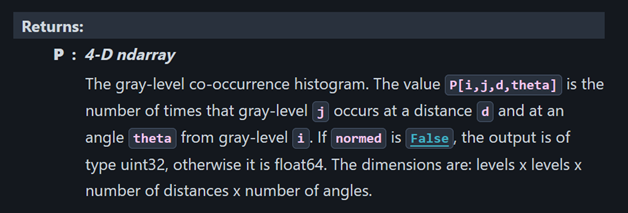

In [401]:
import cv2
import numpy as np
from skimage.feature import graycomatrix, graycoprops

sample_img = cv2.imread(filepaths[0], cv2.IMREAD_GRAYSCALE)

sample_img = sample_img.astype(np.uint8)

dist = [1]
ang = [0]
glcm = graycomatrix(sample_img, distances=dist, angles=ang, levels=256, symmetric=True, normed=True)

print(f"GLCM Shape with 1 distance and 1 angle: {glcm.shape}")

GLCM Shape with 1 distance and 1 angle: (256, 256, 1, 1)


In [402]:
props = ['contrast', 'correlation', 'homogeneity','dissimilarity']
for p in props:
    value = graycoprops(glcm, p)
    print(f"{p}: {value[0,0]:.4f}")

contrast: 585.6870
correlation: 0.8467
homogeneity: 0.0636
dissimilarity: 18.0482


In [403]:
dists = [1, 3, 5] # ۳ فاصله
angs = [0, np.pi/4, np.pi/2] # ۳ زاویه

glcm_multi = graycomatrix(sample_img, distances=dists, angles=angs, levels=256)
print(f"New GLCM Shape with 3 distances and 3 angles: {glcm_multi.shape}")

New GLCM Shape with 3 distances and 3 angles: (256, 256, 3, 3)


#Assignment #4: Create the dataset (X, y) by:

1.   Extracting the GLCM from all images.
2.   Extracting the main properties from the GLCM matrix, six features in total (see [graycoprops](https://scikit-image.org/docs/stable/api/skimage.feature.html#graycoprops)). Employ different values for the  `distances` and `angles` parameters of [skimage.feature.graycomatrix](https://scikit-image.org/docs/stable/api/skimage.feature.html#graycomatrix).
3.   Extract the corresponding numerical label from the filename.




In [404]:
X_glcm = list()
X_glcm_props = list()
y = list()
label_mapping = { "NOK": 1, "DOUBT": 2, "OK": 0}


distances = [1, 2, 4] # فواصل مختلف برای بافت‌های ریز و درشت
angles = [0, np.pi/4, np.pi/2, 3*np.pi/4] # تمام جهات اصلی

properties = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']


for filepath in filepaths:
    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    filename = os.path.basename(filepath).upper() # گرفتن نام فایل و تبدیل به حروف بزرگ

    assigned_label = None
    for key in label_mapping.keys():
        if key in filename:
            assigned_label = label_mapping[key]
            break

    if assigned_label is not None:
        y.append(assigned_label)
    else:
        continue

    glcm = graycomatrix(img, distances=distances, angles=angles, levels=256,
                        symmetric=True, normed=True)
    X_glcm.append(glcm)

    image_features = []
    for prop in properties:
        feat = graycoprops(glcm, prop).ravel()
        image_features.append(feat)

    X_glcm_props.append(np.concatenate(image_features))

X_glcm_props = np.array(X_glcm_props)
y = np.array(y)

print(f"X_glcm_props shape: {X_glcm_props.shape}")
print(f"y shape: {y.shape}")

X_glcm_props shape: (20, 72)
y shape: (20,)


In [405]:
print("Total images found:", len(filepaths))
print("Labels found in 'y':", np.unique(y, return_counts=True))

Total images found: 20
Labels found in 'y': (array([0, 1, 2]), array([7, 5, 8]))


##Assignment #4.1: Reshape the dataset to be fed to sklearn, i.e. a `n_samples by m_features` matrix.
Note that the number of features depends on distances and angles parameters of skimage.feature.graycomatrix

In [406]:

X_glcm_props = X_glcm_props.reshape(len(filepaths), -1)

print(f"Final shape of X_glcm_props: {X_glcm_props.shape}")

Final shape of X_glcm_props: (20, 72)


#Assignment #5: Build and optimize the ML pipeline in a Leave-One-Out (LOO) cross-validation fashion and evaluate leveragin a confusion matrix
1.   Scale the data
2.   Implement PCA
3.   Optimize the hyperparameters of a classifier (e.g., SVM) and train it

> Note that in this case study we have really few samples. For this reason, we opted to built a LOO setting in which we use multiple training set, while at each iteration one single sample is consdiered as the test set. In this way, **we are evaluating a learning method**, not just an individual learned model.





In [407]:
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV

loo = LeaveOneOut()
label_mapping = {"OK": 0, "NOK": 1, "DOUBT": 2}
cm_aggregated = np.zeros((3, 3))

for i, (train_index, test_index) in enumerate(loo.split(X_glcm_props)):

    X_train, X_test = X_glcm_props[train_index], X_glcm_props[test_index]
    y_train, y_test = y[train_index], y[test_index]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    pca = PCA(n_components=0.90)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)


    param_grid = {'C': [1, 10, 50, 100, 500], 'gamma': ['scale', 'auto']}
    weights = {0: 1, 1: 3, 2: 2}

    grid = GridSearchCV(SVC(kernel='rbf', class_weight=weights), param_grid, cv=2)
    grid.fit(X_train_pca, y_train)

    best_clf = grid.best_estimator_

    y_pred = best_clf.predict(X_test_pca)

    cm_aggregated += confusion_matrix(y_test, y_pred, labels=[0, 1, 2])

print("Cross-Validation finished.")

Cross-Validation finished.


## Confusion matrix

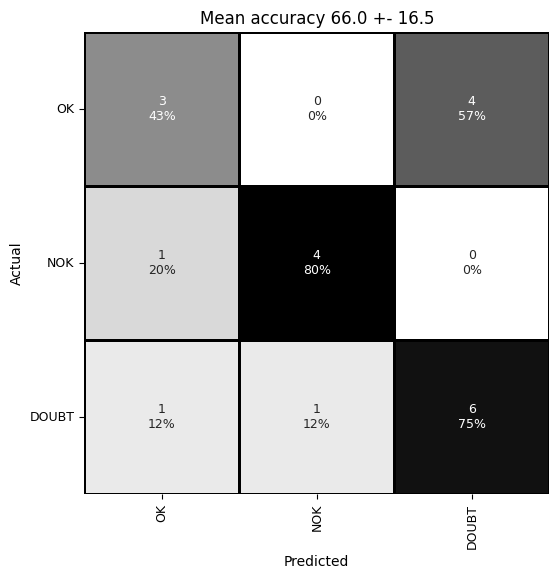

In [408]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
seaborn_cm(cm_aggregated, ax, list(label_mapping.keys()), fontsize=9, xrotation=90)

In [409]:
for label in [0, 1, 2]:
    mean_val = X_glcm_props[y == label].mean()
    print(f"Mean features for class {label}: {mean_val}")

Mean features for class 0: 103.47596041629238
Mean features for class 1: 225.43470134366112
Mean features for class 2: 172.0774550800798
